In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt


In [13]:
class RLAgent:
    def __init__(self, states, actions, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.q_table = np.zeros((states, actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.actions = actions

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.actions - 1)
        return int(np.argmax(self.q_table[state]))

    def update_q_learning(self, s, a, r, s_prime):
        best_next_a = np.argmax(self.q_table[s_prime])
        td_target = r + self.gamma * self.q_table[s_prime][best_next_a]
        self.q_table[s][a] += self.alpha * (td_target - self.q_table[s][a])

    def update_sarsa(self, s, a, r, s_prime, a_prime):
        td_target = r + self.gamma * self.q_table[s_prime][a_prime]
        self.q_table[s][a] += self.alpha * (td_target - self.q_table[s][a])


In [14]:
class GridWorld:
    """
    Grid world for routing task.

    Actions:
        0 = up
        1 = down
        2 = left
        3 = right
    """

    def __init__(self, rows, cols, start=(0, 0), goal=None, danger_zones=None):
        self.rows = rows
        self.cols = cols
        self.start = start
        self.goal = goal if goal is not None else (rows - 1, cols - 1)
        self.danger_zones = set(danger_zones) if danger_zones else set()

        self.num_states = rows * cols
        self.num_actions = 4

    def state_to_index(self, state):
        r, c = state
        return r * self.cols + c

    def index_to_state(self, index):
        return divmod(index, self.cols)

    def reset(self):
        return self.state_to_index(self.start)

    def step(self, state_idx, action):
        r, c = self.index_to_state(state_idx)

        if action == 0:
            r -= 1
        elif action == 1:
            r += 1
        elif action == 2:
            c -= 1
        elif action == 3:
            c += 1

        r = max(0, min(self.rows - 1, r))
        c = max(0, min(self.cols - 1, c))

        next_state = (r, c)
        next_idx = self.state_to_index(next_state)

        if next_state in self.danger_zones:
            return next_idx, -100, True
        elif next_state == self.goal:
            return next_idx, 100, True
        else:
            return next_idx, -1, False


In [15]:
def train_q_learning(env, episodes=500, alpha=0.1, gamma=0.95, epsilon=0.1):
    agent = RLAgent(env.num_states, env.num_actions, alpha=alpha, gamma=gamma, epsilon=epsilon)
    rewards_per_episode = []

    for _ in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(state, action)
            agent.update_q_learning(state, action, reward, next_state)
            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return agent, rewards_per_episode


def train_sarsa(env, episodes=500, alpha=0.1, gamma=0.95, epsilon=0.1):
    agent = RLAgent(env.num_states, env.num_actions, alpha=alpha, gamma=gamma, epsilon=epsilon)
    rewards_per_episode = []

    for _ in range(episodes):
        state = env.reset()
        action = agent.choose_action(state)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, done = env.step(state, action)

            if not done:
                next_action = agent.choose_action(next_state)
                agent.update_sarsa(state, action, reward, next_state, next_action)
                state, action = next_state, next_action
            else:
                agent.q_table[state][action] += agent.alpha * (reward - agent.q_table[state][action])

            total_reward += reward

        rewards_per_episode.append(total_reward)

    return agent, rewards_per_episode


In [16]:
def extract_path(env, agent, max_steps=100):
    state = env.reset()
    path = [env.index_to_state(state)]
    visited = {env.index_to_state(state)}

    for _ in range(max_steps):
        action = int(np.argmax(agent.q_table[state]))
        next_state, reward, done = env.step(state, action)
        next_pos = env.index_to_state(next_state)
        path.append(next_pos)

        if done:
            break

        if next_pos in visited:
            break

        visited.add(next_pos)
        state = next_state

    return path


def moving_average(data, window=20):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode='valid')


def print_grid(env, path=None):
    path = set(path) if path else set()
    for r in range(env.rows):
        row_display = []
        for c in range(env.cols):
            cell = (r, c)
            if cell == env.start:
                row_display.append('S')
            elif cell == env.goal:
                row_display.append('G')
            elif cell in env.danger_zones:
                row_display.append('X')
            elif cell in path:
                row_display.append('*')
            else:
                row_display.append('.')
        print(' '.join(row_display))


def plot_rewards(q_rewards, sarsa_rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(moving_average(q_rewards, 20), label='Q-learning')
    plt.plot(moving_average(sarsa_rewards, 20), label='SARSA')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Reward Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_path(env, path, title):
    grid = np.zeros((env.rows, env.cols))

    for r, c in env.danger_zones:
        grid[r, c] = -1

    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap='gray_r')

    path_rows = [p[0] for p in path]
    path_cols = [p[1] for p in path]
    plt.plot(path_cols, path_rows, marker='o', linewidth=2)

    plt.text(env.start[1], env.start[0], 'S', ha='center', va='center', fontsize=12)
    plt.text(env.goal[1], env.goal[0], 'G', ha='center', va='center', fontsize=12)

    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.title(title)
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.show()


In [17]:
rows = 5
cols = 5
episodes = 500
alpha = 0.1
gamma = 0.95
epsilon = 0.1

start = (0, 0)
goal = (4, 4)
danger_zones = [(1, 2), (2, 2), (3, 2)]

env = GridWorld(rows, cols, start=start, goal=goal, danger_zones=danger_zones)
print('Grid created successfully.')

Grid created successfully.


In [18]:
print_grid(env)

S . . . .
. . X . .
. . X . .
. . X . .
. . . . G


In [19]:
q_agent, q_rewards = train_q_learning(env, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon)
sarsa_agent, sarsa_rewards = train_sarsa(env, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon)

print('Training finished.')

Training finished.


In [20]:
q_path = extract_path(env, q_agent)
sarsa_path = extract_path(env, sarsa_agent)

print('Q-learning path:', q_path)
print('SARSA path:', sarsa_path)

Q-learning path: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4)]
SARSA path: [(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4)]


Q-learning average reward (last 50 episodes): 72.52
SARSA average reward (last 50 episodes): 84.40


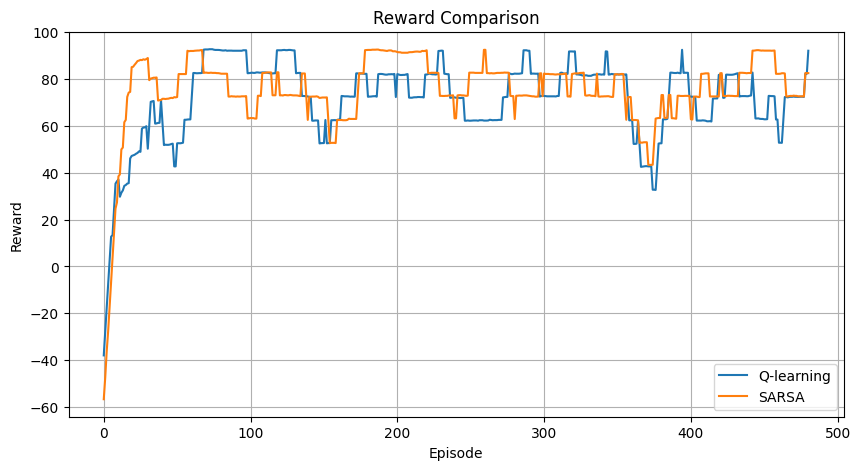

In [21]:
print(f'Q-learning average reward (last 50 episodes): {np.mean(q_rewards[-50:]):.2f}')
print(f'SARSA average reward (last 50 episodes): {np.mean(sarsa_rewards[-50:]):.2f}')

plot_rewards(q_rewards, sarsa_rewards)

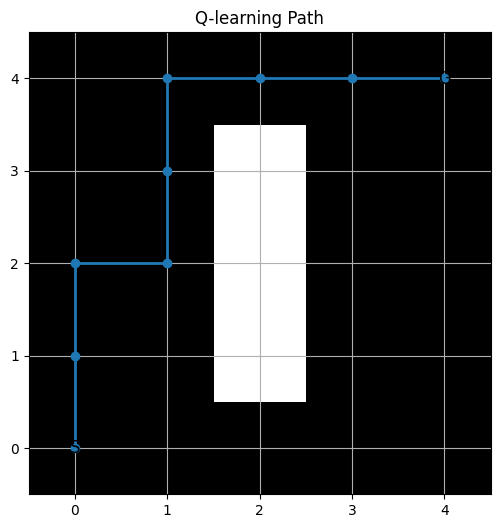

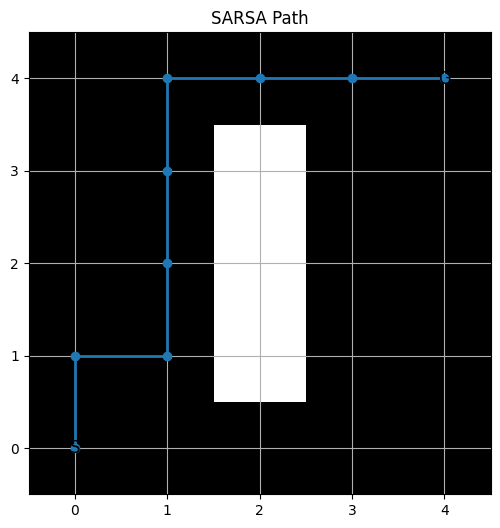

In [22]:
plot_path(env, q_path, 'Q-learning Path')
plot_path(env, sarsa_path, 'SARSA Path')